# Задание: Привести график 10 наиболее успешных фильмов в формате столбчатой диаграммы в порядке уменьшения кассовых сборов с учетом инфляции и без нее. Определить наиболее близкие к медианному и среднему значению сборов фильмы

## 1. Импорты библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pandas: используется для работы с табличными данными (чтение, обработка, анализ).

matplotlib.pyplot: библиотека для построения графиков.

## 2. Загрузка данных

In [2]:
import os

file_path = 'C:/Users/hp/Desktop/МПРР11/ПМИИ/disney_movies_total_gross.csv' 
if os.path.exists(file_path):
    print("Файл найден!")
else:
    print("Файл не найден! Проверьте путь.")

Файл найден!


In [3]:
file_path = 'C:/Users/hp/Desktop/МПРР11/ПМИИ/disney_movies_total_gross.csv'
data = pd.read_csv(file_path)

Загружается файл CSV в переменную data.

pd.read_csv считывает файл и преобразует его в DataFrame (табличный формат).

## 3. Преобразование денежного формата

In [4]:
data['total_gross'] = data['total_gross'].replace('[\$,]', '', regex=True).astype(float)
data['inflation_adjusted_gross'] = data['inflation_adjusted_gross'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\hp\AppData\Local\Temp\ipykernel_5952\3635952903.py:1: SyntaxWarning: invalid escape sequence '\$'
  data['total_gross'] = data['total_gross'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\hp\AppData\Local\Temp\ipykernel_5952\3635952903.py:2: SyntaxWarning: invalid escape sequence '\$'
  data['inflation_adjusted_gross'] = data['inflation_adjusted_gross'].replace('[\$,]', '', regex=True).astype(float)


replace: удаляет символ $ и запятые из строковых значений.

astype(float): преобразует очищенные строки в числовой формат.

Теперь столбцы total_gross и inflation_adjusted_gross содержат числа, что позволяет выполнять математические операции.

## 4. Поиск 10 самых успешных фильмов

In [5]:
top_10_inflation_adjusted = data.nlargest(10, 'inflation_adjusted_gross')
top_10_total = data.nlargest(10, 'total_gross')

nlargest(10, ...): выбирает 10 строк с наибольшими значениями в указанных столбцах:

inflation_adjusted_gross (с учетом инфляции).

total_gross (без учета инфляции).

Результат сохраняется в top_10_inflation_adjusted и top_10_total.

## 5. Построение графиков

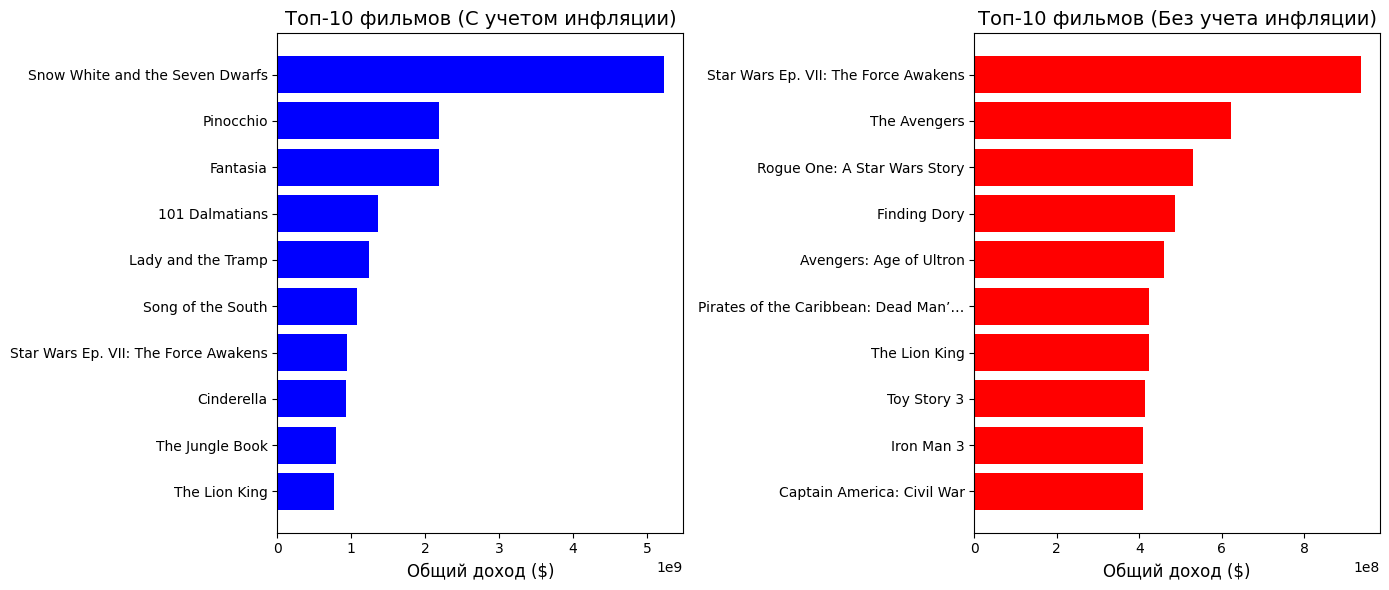

In [6]:
# Построение диаграмм
plt.figure(figsize=(14, 6))

# С учетом инфляции
plt.subplot(1, 2, 1)
plt.barh(top_10_inflation_adjusted['movie_title'], 
         top_10_inflation_adjusted['inflation_adjusted_gross'], color='blue')
plt.title('Топ-10 фильмов (С учетом инфляции)', fontsize=14)
plt.xlabel('Общий доход ($)', fontsize=12)
plt.gca().invert_yaxis()

# Без учета инфляции
plt.subplot(1, 2, 2)
plt.barh(top_10_total['movie_title'], 
         top_10_total['total_gross'], color='red')
plt.title('Топ-10 фильмов (Без учета инфляции)', fontsize=14)
plt.xlabel('Общий доход ($)', fontsize=12)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

figure : Создается область для графиков размером 14x6 дюймов.

subplot(1, 2, 1): указывает, что будет два графика (1 ряд, 2 столбца), текущий график — первый.

barh: горизонтальная столбчатая диаграмма.

Ось Y — названия фильмов (movie_title).

Для График 1: Ось X — кассовые сборы с учетом инфляции или без учета инфляции (inflation_adjusted_gross).

Для График 2: Ось X — кассовые сборы Без учета инфляции (top_10_total).

tight_layout: добавляет отступы между графиками.

show: отображает диаграммы.

## 6. Расчет медианы и среднего

In [7]:
median_inflation_adjusted = data['inflation_adjusted_gross'].median()
mean_inflation_adjusted = data['inflation_adjusted_gross'].mean()

median_total_gross = data['total_gross'].median()
mean_total_gross = data['total_gross'].mean()

median: вычисляет медиану — значение, находящееся посередине упорядоченного набора данных.

mean: вычисляет среднее значение.

## 7. Поиск ближайших к медиане и среднему фильмов

In [8]:
closest_to_median_inflation = data.iloc[(data['inflation_adjusted_gross'] - median_inflation_adjusted).abs().idxmin()]
closest_to_mean_inflation = data.iloc[(data['inflation_adjusted_gross'] - mean_inflation_adjusted).abs().idxmin()]

closest_to_median_total = data.iloc[(data['total_gross'] - median_total_gross).abs().idxmin()]
closest_to_mean_total = data.iloc[(data['total_gross'] - mean_total_gross).abs().idxmin()]

(data[...] - value).abs(): находит разницу между значениями и медианой (или средним), берет модуль (абсолютное значение).

idxmin(): индекс строки с минимальной разницей.

iloc: извлекает строку по индексу.

То же самое выполняется для total_gross.

## 8. Вывод результатов

In [10]:
print("С учетом инфляции:")
print(f"Медиана: ${median_inflation_adjusted}, Ближайший фильм: {closest_to_median_inflation['movie_title']}")
print(f"Среднее: ${mean_inflation_adjusted}, Ближайший фильм: {closest_to_mean_inflation['movie_title']}")

print("\nБез учета инфляции:")
print(f"Медиана: ${median_total_gross}, Ближайший фильм: {closest_to_median_total['movie_title']}")
print(f"Среднее: ${mean_total_gross}, Ближайший фильм: {closest_to_mean_total['movie_title']}")

С учетом инфляции:
Медиана: $55159783.0, Ближайший фильм: James and the Giant Peach
Среднее: $118762523.31088082, Ближайший фильм: Honey I Blew Up the Kid

Без учета инфляции:
Медиана: $30702446.0, Ближайший фильм: Toy Story 3D Double Feature
Среднее: $64701788.51986183, Ближайший фильм: Song of the South
